# A/B Testing: Power Analysis, Bootstrap CI and Type II Error Simulation

**Цель:** Исследование статистической мощности A/B теста на примере бинарной метрики (конверсия) с MDE = 5%.

**Содержание:**
1. Симуляция распределений и ЦПТ
2. Доверительные интервалы (бутстрап и теоретический расчет)
3. Расчёт мощности и ошибки II рода
4. Симуляция 1000 A/B тестов
5. Калибровка A/A теста

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
from tqdm import tqdm

%config InlineBackend.figure_format = 'svg'

In [2]:
def calc_stat_random_sample(mu=5, sigma2=4, size=100):
    random_sample = sps.norm.rvs(loc=mu, scale=np.sqrt(sigma2), size=size)
    mean = random_sample.mean()
    median = np.median(random_sample)
    std = random_sample.std()
    return(mean, std, median)

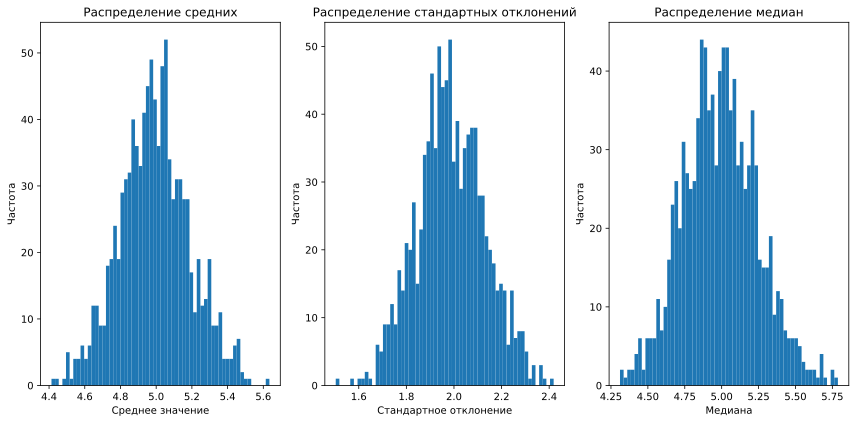

In [3]:
n_samples = 1000
means = np.zeros(n_samples)
medians = np.zeros(n_samples)
std_s = np.zeros(n_samples)

for i in range(n_samples):
  means[i], std_s[i], medians[i] = calc_stat_random_sample()

fig, axes = plt.subplots(1, 3, figsize = (12, 6))
params = [
  (means, 'Распределение средних', 'Среднее значение'),
  (std_s, 'Распределение стандартных отклонений', 'Стандартное отклонение'),
  (medians, 'Распределение медиан', 'Медиана')]

for i, (data, title, xlabel) in enumerate(params):
    axes[i].hist(data, bins=60)
    axes[i].set_title(title)
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

Какому распределению принадлежит распределение средних? Почему?

**Вывод:** Распределение выборочных средних соответствует нормальному распределению согласно ЦПТ

### ММП

Оценка значения $\hat{\mu}$ параметра $\mu$ для нормального распределения $\mathscr{N}(\mu,1)$ используя метод максимального правдоподобия.

Справка: функция плотности распределения для нормального распределения имеет вид:
$$
    f(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} \text{e}^{-\frac{(x - \mu)^2}{2 \sigma^2}}
$$

Функция правдоподобия $$L(\mu) = \prod_{i=1}^n f(x = x_i, \mu) = (\frac{1}{\sqrt{2 \pi}})^n \cdot \text{e}^{-\frac{\sum_{i=1}^n (x_i-\mu)^2}{2}}$$

Её логарифм: $$ l(\mu) = \ln L(\mu) = n\ln \frac{1}{\sqrt{2 \pi}} - \frac{1}{2} \sum_{i=1}^n (x_i-\mu)^2 $$

Дифференцируем: $$ \frac{d}{d \mu} l(\mu) = -\frac{1}{2} \sum_{i=1}^n -2(x_i-\mu) = \sum_{i=1}^n (x_i-\mu) = \sum_{i=1}^n x_i - n\mu $$

Ищем экстремум: $$\sum_{i=1}^n x_i - n\mu = 0$$ откуда получаем
$$\hat{\mu} = \frac{1}{n} \sum_{i=1}^n x_i = \bar{x}$$

**Вывод:** Оценка максимального правдоподобия для параметра μ нормального распределения 
совпадает с выборочным средним. Это свойство несмещённости и состоятельности оценки

Сгенерируйте 1000 выборок размером 1000 наблюдений из нормального распределения с $\mu = 5, \sigma^2 = 1$, постройте распределение разности $\mu - \hat{\mu}$ и найдите среднее этой разности в зависимости от числа выборок.

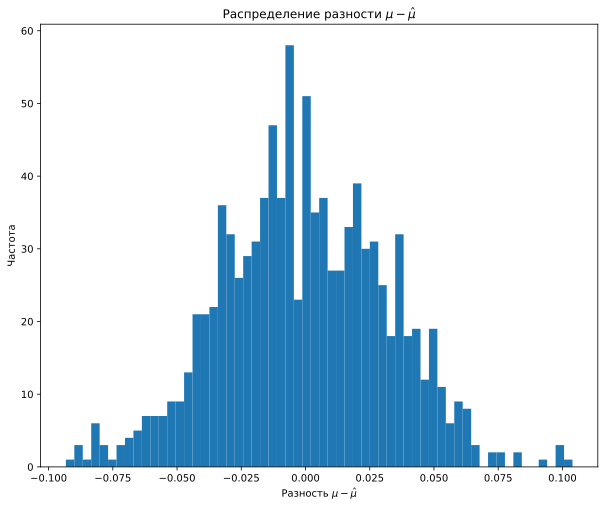

In [4]:
n_samples = 1000
mu = 5
sigma2 = 1
size = 1000

stats_deltas = np.zeros(n_samples)
for i in range(n_samples):
  random_sample = sps.norm.rvs(loc=mu, scale=np.sqrt(sigma2), size=size)
  cur_mean = random_sample.mean()
  stats_deltas[i] = mu - cur_mean

plt.figure(figsize=(10,8))
plt.hist(stats_deltas, bins = 60)
plt.title(r'Распределение разности $\mu - \hat{\mu}$')
plt.xlabel(r'Разность $\mu - \hat{\mu}$')
plt.ylabel('Частота')
plt.show()

100%|██████████| 109/109 [03:28<00:00,  1.92s/it]


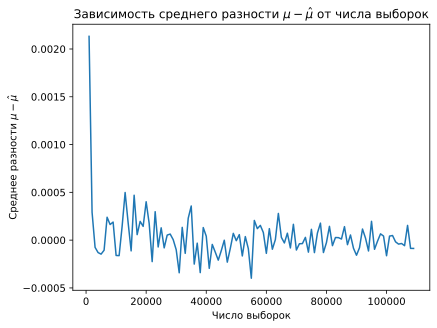

In [5]:
def sample_stat_delta(n_samples = 1000, mu = 5, sigma2 = 1, size = 1000):
  all_samples = sps.norm.rvs(loc=mu, scale=np.sqrt(sigma2), size=(n_samples, size))
  sample_means = np.mean(all_samples, axis=1)
  deltas = mu - sample_means
  return deltas.mean()

n_abs = np.arange(1000, 110000, 1000)
delta_mu_means = []
for n in tqdm(n_abs):
    cur_delta_mean =  sample_stat_delta(n_samples=n)
    delta_mu_means.append(cur_delta_mean)

plt.plot(n_abs, delta_mu_means)
plt.title(r'Зависимость среднего разности $\mu - \hat{\mu}$ от числа выборок')
plt.xlabel('Число выборок')
plt.ylabel(r'Среднее разности $\mu - \hat{\mu}$')
plt.show()


### Доверительные интервалы

Пусть известно, что выборка в n наблюдений порождена распределением Бернулли ~Bernoulli(p), пусть среднее значение по выборке равно $\hat{p}$. Постройте формулу 95% доверительного интервал для среднего

Согласно ЦПТ, выборочное среднее распределено нормально. Тогда 95% доверительный интервал имеет вид:
$$ \hat{p} \pm 1.96 \sqrt{\frac{\hat{p} \cdot (1 - \hat{p})}{n}}$$

Постройте 95% доверительный интервал на среднее в представленной выборке, используя бутстрап и сравните с теоретическим значением

In [6]:
X = sps.bernoulli.rvs(0.2, size = 10000, random_state=42)
B = 10000
n = 10000
alpha = 0.05

bootstrap_mean_values = []
for i in range(B):
  bootstrap_sample = np.random.choice(a=X, size=n, replace=True)
  bootstrap_sample_mean = bootstrap_sample.mean()
  bootstrap_mean_values.append(bootstrap_sample_mean)

left = np.quantile(np.array(bootstrap_mean_values), alpha/2)
right = np.quantile(np.array(bootstrap_mean_values), 1 - alpha/2)

p_hat = X.mean()
left_teor = p_hat - 1.96 * np.sqrt(p_hat*(1-p_hat)/n)
right_teor = p_hat + 1.96 * np.sqrt(p_hat*(1-p_hat)/n)

print(f'Эмпирический 95% CI для среднего: [{left:.4f}, {right:.4f}]')
print(f'Теоретический 95% CI для среднего: [{left_teor:.4f}, {right_teor:.4f}]')

Эмпирический 95% CI для среднего: [0.1884, 0.2041]
Теоретический 95% CI для среднего: [0.1884, 0.2040]


### А/B тестирование

Основным критерием для тестирования гипотезы о равенстве средних является t-test. Он строится на том, что по ЦПТ практически для любой случайной величины средние будут распределены нормально.

В учебниках по статистике доказывается, что в силу этого для двух выборок, порождённых одинаково распределёнными независимыми случайными величинами с равным средним мы имеем асимпототику для выборочной t-статистики
$$
    T = \frac{\bar{x} - \bar{y}}{\sqrt{\frac{s_x^2}{n_1} + \frac{s_y^2}{n_2}}} \rightarrow t_{n_1 + n_2 - 2},
$$
где $\bar{x}, \bar{y}$ -- выборочные средние в выборках, $s_x^2, s_y^2$ -- выборочные дисперсии, $n_1, n_2$ -- размеры выборок, а $t_{n_1 + n_2 - 2}$ -- распределение Стьюдента с $n_1 + n_2 - 2$ степенями свободы.

Постройте плотность распределения Стьюдента с 1, 5, 10, 100 и 1000 степеней свободы, а также плотность стандартного нормального распределения

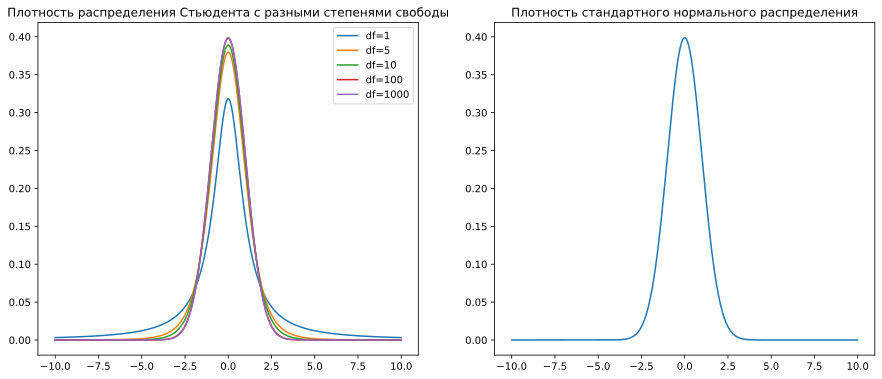

In [7]:
grid = np.arange(-10,10,0.01)

freedom_degrees = [1,5,10,100,1000]

fig, axes = plt.subplots(1,2,figsize=(15,6))
for deg in freedom_degrees:
  axes[0].plot(grid, sps.t.pdf(grid, df=deg), label=f'df={deg}')

axes[1].plot(grid, sps.norm.pdf(grid))

axes[0].legend()
axes[0].set_title('Плотность распределения Стьюдента с разными степенями свободы')
axes[1].set_title('Плотность стандартного нормального распределения')
plt.show()

Пусть нам необходимо запустить A/B тест: в первой группе мы оставляем кнопку в банковском приложении в сером цвете, во втором -- красим её в жёлтый. Всего у нас в месяц в приложение заходит 1000 различных клиентов. Базовая конверсия в нажатие кнопки сейчас составляет 0.2. Бизнес постановил, что MDE = 5%, то есть значимым будет считаться изменение, при котором конверсия будет больше 0.21 или меньше 0.19. Хватит ли нам данных, чтобы замерить эффект за один месяц при уровне значимости $\alpha = 0.05$, если мы планируем поделить выборку пополам на тест и контроль?

In [8]:
n_total = 1000
n1 = n2 = n_total / 2
cr_base = 0.2
mde_rel = 0.05
mde_abs = cr_base * mde_rel

var = cr_base * (1 - cr_base)
se = np.sqrt(var/n1 + var/n2)

t_stat = mde_abs / se
p_value = 2 * (1 - sps.t.cdf(np.abs(t_stat), df=n1+n2-2))

print(f't-статистика: {t_stat:.4f}')
print(f'p-value: {p_value:.4e}')

if p_value < 0.05:
    print('\nВывод:')
    print('  Отвергаем нулевую гипотезу (H0). Данных хватит.')
else:
    print('\nВывод:')
    print('  Не удалось отвергнуть нулевую гипотезу (H0). Данных не хватит.')

t-статистика: 0.3953
p-value: 6.9272e-01

Вывод:
  Не удалось отвергнуть нулевую гипотезу (H0). Данных не хватит.


Можно посмотреть с другой стороны и попробовать рассчитать минимальную длительность теста, чтобы задетектировать желаемый эффект при данном размере выборке (и взять стандартную мощность теста 0.8, то есть $\beta$ = 0.2):

In [17]:
clients_per_month = 1000
CR = 0.2
MDE_rel = 0.05
MDE_abs = CR * MDE_rel
alpha = 0.05
sigma2 = CR * (1-CR)
beta = 0.2

dist = sps.norm(loc=0, scale=1)
const = (dist.ppf(1-alpha/2) + dist.ppf(1-beta)) ** 2
n_min = (2*sigma2*const)/(MDE_abs)**2 # кол-во чел в одну группу
ab_duration = n_min / (clients_per_month / 2)

print(f'Длительность А/В теста, чтобы задетектировать MDE = 5%: {int(np.ceil(ab_duration))} месяц')

Длительность А/В теста, чтобы задетектировать MDE = 5%: 51 месяц


**Вывод**: нам не хватит данных, чтобы замерить эффект за один месяц при уровне значимости 0.05

Мы провели тест и получили следующие результаты:

In [10]:
X_1, X_2 = sps.bernoulli.rvs(0.2, size = 1000, random_state=42), sps.bernoulli.rvs(0.21, size = 1000, random_state=42)

Можем ли мы утверждать на уровне значимости $\alpha = 0.05$, что эффект имел место быть?

In [11]:
#t-test ручками
n1 = n2 = 1000
s_1 = X_1.var()
s_2 = X_2.var()
CR_1 = X_1.mean()
CR_2 = X_2.mean()

se = np.sqrt(s_1/n1 + s_2/n2)
t_stat = (CR_2 - CR_1) / se
p_value = 2 * (1 - sps.t.cdf(x=t_stat, df=n1+n2-2))

print(f't-статистика: {t_stat:.4f}')
print(f'p-value: {p_value:.4e}')

if p_value < 0.05:
    print('\nВывод:')
    print('  Отвергаем нулевую гипотезу (H0).')
else:
    print('\nВывод:')
    print('  Не удалось отвергнуть нулевую гипотезу (H0).')

t-статистика: 0.6647
p-value: 5.0629e-01

Вывод:
  Не удалось отвергнуть нулевую гипотезу (H0).


In [12]:
#Welch's t-test
res = sps.ttest_ind(X_2, X_1, equal_var=False)

print(f't-статистика: {res.statistic:.4f}')
print(f'p-value: {res.pvalue:.4e}')
if res.pvalue < 0.05:
    print('\nВывод:')
    print('  Отвергаем нулевую гипотезу (H0).')
else:
    print('\nВывод:')
    print('  Не удалось отвергнуть нулевую гипотезу (H0).')

t-статистика: 0.6644
p-value: 5.0650e-01

Вывод:
  Не удалось отвергнуть нулевую гипотезу (H0).


**Вывод**: нет, мы не можем утверждать на уровне значимости  $\alpha$=0.05 , что эффект имел место быть

Что будет, если мы проведём 1000 таких тестов, "отпустив" random_state?

В какой доле случаев мы не задетектируем это существующее различие? Чему будет равна $\beta$?

In [13]:
def statisctics_for_ab_test(n1 = 1000, n2 = 1000, p1 = 0.2, p2 = 0.21):
    X_1, X_2 = sps.bernoulli.rvs(p1, size = n1), sps.bernoulli.rvs(p2, size = n2)
    s_1 = X_1.var()
    s_2 = X_2.var()
    CR_1 = X_1.mean()
    CR_2 = X_2.mean()

    se = np.sqrt(s_1/n1 + s_2/n2)
    t_stat = (CR_2 - CR_1) / se
    p_value = 2 * (1 - sps.t.cdf(x=t_stat, df=n1+n2-2))
    return p_value

Если мы проведём 1000 таких тестов, "отпустив" random_state, то каждый тест генерирует новые случайные выборки из Bernoulli(0.2) и Bernoulli(0.21)

In [18]:
# Под "отпущенным" random_state понимается None
# X_1, X_2 = sps.bernoulli.rvs(0.2, size = 1000), sps.bernoulli.rvs(0.21, size = 1000)

number_tests = 1000
fn = 0
for i in range(number_tests):
    cur_pvalue = statisctics_for_ab_test()
    if cur_pvalue >= 0.05:
        fn += 1

beta = fn / number_tests
print(f'𝛽 =', beta)
print(f'Мы не задетектируем это существующее различие в {beta:.2f} доле случаев')

𝛽 = 0.914
Мы не задетектируем это существующее различие в 0.91 доле случаев


Таким образом, мощность теста составляет всего около 8%. То есть у нас лишь 8% шанс заметить эффект, даже если он есть

А если различий не будет (при проведении 1000 A/A-тестов)? Как будет распределено p-value в этом случае?

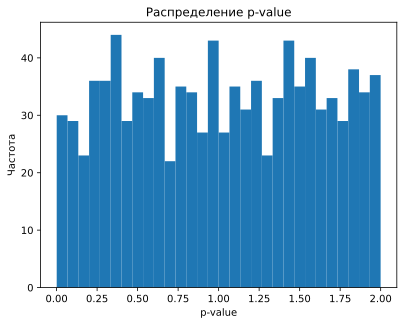

In [19]:
# Под A/A тестом имеем в виду: X_1, X_2 = sps.bernoulli.rvs(0.2, size = 1000), sps.bernoulli.rvs(0.2, size = 1000)

number_tests = 1000
rejected_H1 = 0
pvalue_tt = []
for i in range(number_tests):
    cur_pvalue = statisctics_for_ab_test(p2 = 0.2)
    pvalue_tt.append(cur_pvalue)

plt.figure()
plt.hist(pvalue_tt, bins = 30)
plt.title('Распределение p-value')
plt.xlabel('p-value')
plt.ylabel('Частота')
plt.show()

При отсутствии реального эффекта (A/A тест) p-value распределено равномерно на [0,1]. Это подтверждает корректную 
калибровку теста: уровень значимости α = 0.05 соответствует доле ложноположительных результатов 5%